# Demonstração: k-means com vinhos

Nesta demonstração, seguimos um fluxo simples e alinhado às Aulas 6. O objetivo é aplicar k-means ao conjunto de dados de vinhos, visualizar os grupos e discutir como escolher o número de clusters. A variável `qualidade` é usada apenas para interpretação posterior, não para treino.

## 1. Importações e configuração
Aqui carregamos as bibliotecas necessárias e definimos o caminho do dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline

SEED = 42
DATA_PATH = Path('datasets/winequality-red.csv')

## 2. Carregar dados
O dataset contém variáveis físico-químicas e a coluna de qualidade.

In [2]:
df = pd.read_csv(DATA_PATH)

df = df.rename(columns={
    'fixed acidity': 'acidez_fixa',
    'volatile acidity': 'acidez_volatil',
    'citric acid': 'acido_citrico',
    'residual sugar': 'acucar_residual',
    'chlorides': 'cloretos',
    'free sulfur dioxide': 'dioxido_de_enxofre_livre',
    'total sulfur dioxide': 'dioxido_de_enxofre_total',
    'density': 'densidade',
    'pH': 'ph',
    'sulphates': 'sulfatos',
    'alcohol': 'alcool',
    'quality': 'qualidade',
})

df.head()

,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_de_enxofre_livre,dioxido_de_enxofre_total,densidade,ph,sulfatos,alcool,qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Inspeção rápida
Vamos verificar tamanho e valores ausentes.

In [3]:
df.shape, df.isna().sum().max()

((1599, 12), np.int64(0))

## 4. Separar features e alvo
A coluna `qualidade` será usada apenas para interpretação posterior.

In [4]:
X = df.drop('qualidade', axis=1)
y = df['qualidade']

X.head()

,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_de_enxofre_livre,dioxido_de_enxofre_total,densidade,ph,sulfatos,alcool
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


## 5. Padronização
Como k-means usa distância, padronizamos as variáveis.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. K-means com k=10 (referência)
Usamos k=10 como valor inicial, seguindo a escala de qualidade possível no dataset.

In [6]:
kmeans_10 = KMeans(n_clusters=10, random_state=SEED, n_init='auto')
labels_10 = kmeans_10.fit_predict(X_scaled)

np.unique(labels_10, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32),
 array([477, 193,  24,  39, 210,  11, 195, 144,  35, 271]))

## 7. Visualização com PCA
Projetamos os dados em 2D para visualizar a separação entre clusters.

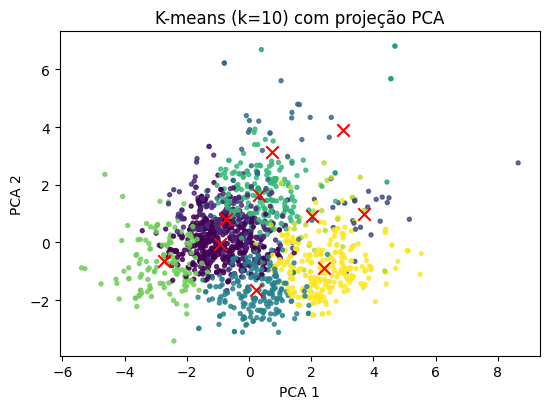

In [7]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans_10.cluster_centers_)

plt.figure(figsize=(5.6, 4.2))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_10, cmap='viridis', s=8, alpha=0.8)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=80, marker='x')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-means (k=10) com projeção PCA')
plt.tight_layout()
plt.show()

## 8. Método do cotovelo
Calculamos a inércia para diferentes valores de k e buscamos o ponto de inflexão.

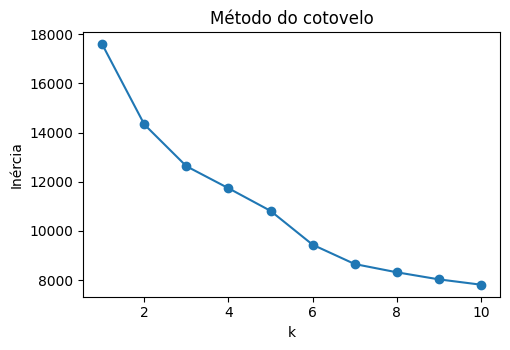

In [8]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(5.2, 3.6))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inércia')
plt.title('Método do cotovelo')
plt.tight_layout()
plt.show()

## 9. K-means com k=5
Após inspecionar o cotovelo, ajustamos k=5 e repetimos a visualização.

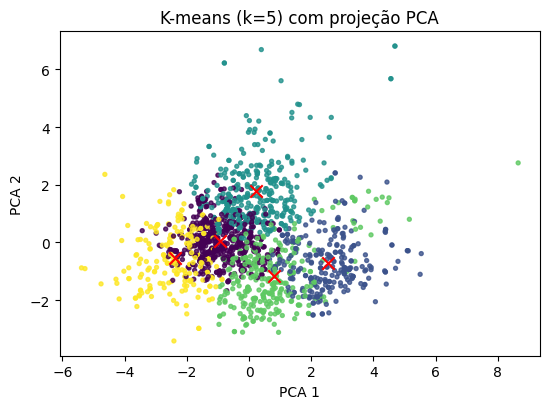

In [9]:
kmeans_5 = KMeans(n_clusters=5, random_state=SEED, n_init='auto')
labels_5 = kmeans_5.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans_5.cluster_centers_)

plt.figure(figsize=(5.6, 4.2))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_5, cmap='viridis', s=8, alpha=0.8)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=80, marker='x')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-means (k=5) com projeção PCA')
plt.tight_layout()
plt.show()

## 10. Interpretação com a variável `qualidade`
A variável `qualidade` não entrou no treinamento; usamos apenas para interpretar os grupos.

In [10]:
y.value_counts().sort_index()

qualidade
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [11]:
pd.crosstab(y, labels_5, normalize='index').round(2)

col_0,0,1,2,3,4
qualidade,,,,,
3,0.70,0.20,0.10,0.00,0.00
4,0.58,0.08,0.11,0.04,0.19
5,0.42,0.12,0.33,0.08,0.05
6,0.27,0.19,0.14,0.21,0.19
7,0.09,0.24,0.06,0.45,0.16
8,0.00,0.28,0.00,0.50,0.22


## 11. Observações finais

A análise mostra que o número de clusters é uma escolha interpretativa e depende do objetivo do projeto. A distribuição de `qualidade` por cluster ajuda a entender quais grupos capturam variações reais, mas não é uma avaliação definitiva da qualidade dos clusters.